# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:**Amara latif
**Student ID:**023-24-0012
**Section:**B
**GitHub:**
**Kaggle:**
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [26]:
#YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
This dataset allow us to predict the selling price of house based on its characteristics, such as living area , quality , location and year built. This can help buyers , sellers , and real- estate estimate house's expected market value.

**Answer 2:**
This is a regression problem because Saleprice is continous numerical value, rather than a category or class. Therefore, the model will be evaluated using regression metrics such as RMSE, MAE, R^2 , instead of classification metrics like accuracy or precision.

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [27]:
# Task 3 — load and inspect the dataset
import pandas as pd
df = pd.read_csv('train.csv')

print("Shape:" , df.shape)

print("first 5 rows of the dataset:")
print(df.head())

print("Dataset information:")
df.info()

print("Summary statistics:")
print(df.describe())



Shape: (1460, 81)
first 5 rows of the dataset:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

**Observations:**
*The dataset contains 1,460 houses and 81 columns.
*It contains both numerical and categorical features.
*The Saleprice value have a wide range, meaning house price vary considerably.
*Some features contains missing values ,which may need to be  handled before modeling. 
*The dataset contains different types of information about houses, such as area , quality , year built , garage, and neighbourhood.
_(what did you notice about the data — size, ranges, any obvious oddities?)

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: _SalesPrice______

Numerical independent variables: ____
GrLivArea
OverallQual
TotalBsmtSF
GarageCars
YearBuilt
FullBath
1stFlrSF
GarageArea___

Categorical independent variables: _
Neighborhood
HouseStyle
KitchenQual______

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [33]:
# Task 5 — define X and y, encode categorical columns
features=[
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "GarageArea",
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]
X = df[features]
y = df['SalePrice']

X = pd.get_dummies(
    X,
    columns=["Neighborhood", "HouseStyle", "KitchenQual"],
    drop_first= True
)
print("X shape:" , X.shape)
print("Y shape:",  y.shape)

X shape: (1460, 42)
Y shape: (1460,)


In [29]:
# Task 7 — confirm X is fully numeric with no missing values
print(X.dtypes)

#check whether all columns are numneric
print("All numeric columns:" ,X.select_dtypes(exclude="number").shape[1] ==0)

#total missing values in X
print("Total missing values in X:" , X.isnull().sum().sum())
      

GrLivArea               int64
OverallQual             int64
TotalBsmtSF             int64
GarageCars              int64
YearBuilt               int64
FullBath                int64
1stFlrSF                int64
GarageArea              int64
Neighborhood_Blueste     bool
Neighborhood_BrDale      bool
Neighborhood_BrkSide     bool
Neighborhood_ClearCr     bool
Neighborhood_CollgCr     bool
Neighborhood_Crawfor     bool
Neighborhood_Edwards     bool
Neighborhood_Gilbert     bool
Neighborhood_IDOTRR      bool
Neighborhood_MeadowV     bool
Neighborhood_Mitchel     bool
Neighborhood_NAmes       bool
Neighborhood_NPkVill     bool
Neighborhood_NWAmes      bool
Neighborhood_NoRidge     bool
Neighborhood_NridgHt     bool
Neighborhood_OldTown     bool
Neighborhood_SWISU       bool
Neighborhood_Sawyer      bool
Neighborhood_SawyerW     bool
Neighborhood_Somerst     bool
Neighborhood_StoneBr     bool
Neighborhood_Timber      bool
Neighborhood_Veenker     bool
HouseStyle_1.5Unf        bool
HouseStyle

**Answer 6 (encoding justification):**
We use one-Hot encoding  for the categorical columns Neighborhood, HouseStyle, and KitchenQual because these columns contains categories/labels rather than meaningful numerical values.pd.get_dummies converts each category in to separate 0/1 numeric columns, making the data suitable for Linear regression.

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [34]:
# Task 8 — train/test split, report shapes


from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2 , random_state= 42)

print("X_train_shape: " , X_train.shape)
print("X_test_shape: " , X_test.shape)
print("y_train_shape: " , y_train.shape)
print("y_test_shape: ", y_test.shape)

X_train_shape:  (1168, 42)
X_test_shape:  (292, 42)
y_train_shape:  (1168,)
y_test_shape:  (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [36]:
# Task 9 — train the Linear Regression model
from sklearn.linear_model import LinearRegression

#create a model 
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](42,)","[ 69.62, 13020.69, 11.56,...,-53068.11,-44828.86,-53667.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](42,)","['GrLivArea','OverallQual','TotalBsmtSF',...,'KitchenQual_Fa', 'KitchenQual_Gd','KitchenQual_TA']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.945e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,42
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(42)


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [37]:
# Task 10 — generate predictions, compare actual vs predicted
y_pred = model.predict(X_test)

 #compare actual vs predicted prices for 10 houses
comparison = pd.DataFrame({
    "Actual price": y_test,
    "Predicted Price": y_pred
    })

print(comparison.head(10))  

      Actual price  Predicted Price
892         154500    138672.599197
1105        325000    323302.912596
413         115000    113402.876873
522         159000    175295.923686
1036        315500    317235.493713
614          75500     68057.354354
218         311500    234614.749188
1160        146000    144773.829430
649          84500     67650.271315
887         135500    117523.023718


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
| | |
| | |
| | |

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [38]:
# Task 11 — extract intercept and coefficients

print("Intercept:", model.intercept_)

coefficient_table = pd.DataFrame({
    "Features": X.columns,
    "Coefficient": model.coef_
})

def interpretation(coef):
    if coef > 0:
        return f"A one-unit increase is associated with an increase of approximately {coef:.2f} in predicted price, holding other features constant."
    else:
        return f"A one-unit increase is associated with a decrease of approximately {abs(coef):.2f} in predicted price, holding other features constant."

coefficient_table["Interpretation"] = coefficient_table["Coefficient"].apply(interpretation)

print(coefficient_table)


#Coefficient tells how much the predicted house price changes when a feature increases by 1 unit, keeping other features constant.
#Interpretation explains the coefficient in simple words.
#Intercept is the predicted house price when all features are 0.


Intercept: -394548.3805050098
                Features   Coefficient  \
0              GrLivArea     69.622452   
1            OverallQual  13020.693586   
2            TotalBsmtSF     11.556286   
3             GarageCars   9815.474730   
4              YearBuilt    203.541519   
5               FullBath    -53.833055   
6               1stFlrSF    -23.284360   
7             GarageArea      6.896131   
8   Neighborhood_Blueste   1627.494900   
9    Neighborhood_BrDale    989.747091   
10  Neighborhood_BrkSide  22595.634512   
11  Neighborhood_ClearCr  53095.783784   
12  Neighborhood_CollgCr  23630.382943   
13  Neighborhood_Crawfor  46840.913185   
14  Neighborhood_Edwards   4771.004129   
15  Neighborhood_Gilbert  24360.245441   
16   Neighborhood_IDOTRR  11804.584247   
17  Neighborhood_MeadowV   4760.184977   
18  Neighborhood_Mitchel  14826.165157   
19    Neighborhood_NAmes  14727.584799   
20  Neighborhood_NPkVill  10657.712479   
21   Neighborhood_NWAmes  16863.243745   
22  

**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---|---|
| | | |
| | | |
| | | |

**Answer 12:**
No , The intercept does not have a sensible real world interpretation for this dataset. The intercept represnets the predicted house price when all the features are zero, but a house with zero livin area ,zero quality m zeri year built and other features equal to zero is unrealistic, Therefore , the intercept is mainly a mathematical part of teh regression model rather than a meaningful real-world house price.

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

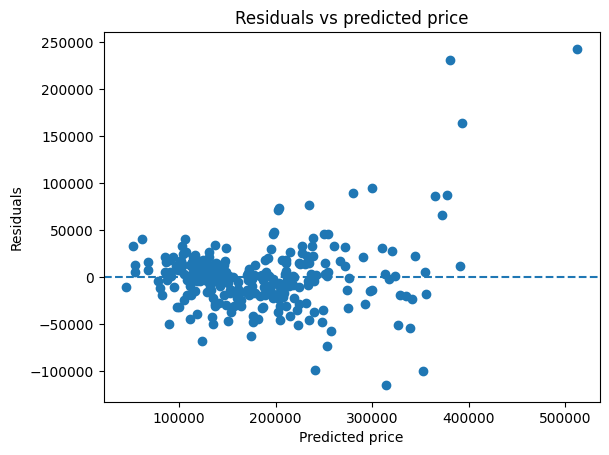

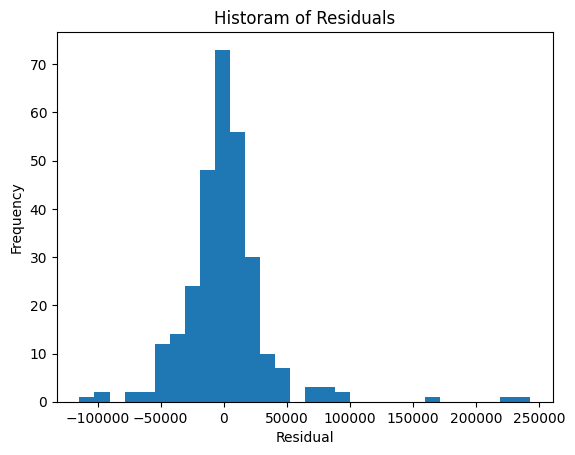

In [39]:
# Task 13 — compute and plot residuals
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0 , linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.title("Residuals vs predicted price")
plt.show()

#Histogram of residuals 
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Historam of Residuals")
plt.show()



**Answer 13:**
The residuals to be randomly scattered around zero with no strong visible pattern. This suggestes that the model's errors do not follow a cleat systematic pattern. The histogram shows the distribution of the residuals and helps us to understand how the prediction errors are spread.

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [41]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test , y_pred)

metrics_table = pd.DataFrame({
    "Metric" : ["MAE ", "MSE" , "RMSE" ,"R^2"],
    "Value" : [mae,mse,rmse,r2]
})

print(metrics_table)


  Metric         Value
0   MAE   2.126436e+04
1    MSE  1.226512e+09
2   RMSE  3.502160e+04
3    R^2  8.400964e-01


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE | |
| MSE | |
| RMSE | |
| R² | |

**Answer 15:**
**MAE:** It tells us the average difference between the actual and predicted house prices.

**MSE:** It measures the average squared prediction error and gives more importance to larger errors.

**RMSE:** It tells us the typical prediction error while giving more weight to large errors.

**R²:** It tells us how well the model explains the variation in house prices. A higher R² generally indicates a better fit.

For a non-technical stakeholder, I would show **MAE** because it is easy to understand. It directly tells us how much the model's predictions are wrong on average in the same units as the house price.


---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [46]:
# Task 16 — compute training-set metrics
y_train_pred = model.predict(X_train)

#training metrics
train_mae= mean_absolute_error(y_train , y_train_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train , y_train_pred)

#comparison table
comparison_table= pd.DataFrame({
    "Metric": ["MAE" , "MSE" , "RMSE" ,"R2"],
    "Training":[train_mae , train_mse , train_rmse , train_r2],
    "Testing":[mae,mse,rmse,r2]
})

print(comparison_table)


  Metric      Training       Testing
0    MAE  2.061963e+04  2.126436e+04
1    MSE  1.052001e+09  1.226512e+09
2   RMSE  3.243456e+04  3.502160e+04
3     R2  8.236245e-01  8.400964e-01


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE | | |
| MSE | | |
| RMSE | | |
| R² | | |

**Answer 17:**
There is no  gap between traing and testing performance.The training and testing metrics are reasonably close , which suggests that the model is not strongly overfitting and is able to generalize reasonably well to unseen data. A large gap between training and testing performance would suggests overfitting , where the model performs very well on training data but poorly on new data.

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
The 2–3 features that appear most influential on house price are **Neighborhood_NoRidge (75,987.01)**, **Neighborhood_ClearCr (53,095.78)**, and **Neighborhood_Crawfor (46,840.91)** because they have some of the largest absolute coefficient values in the coefficient table. These positive coefficients indicate that, compared with the reference neighborhood, houses in these neighborhoods are associated with higher predicted prices, holding the other features constant. However, coefficient magnitudes should be interpreted carefully because different features have different scales and units. For example, `GrLivArea` is measured in square feet, while neighborhood variables are one-hot encoded categories. Therefore, a larger coefficient does not automatically mean that a feature is more important overall.


---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The Linear Regression model predicts house prices reasonably well using the selected numerical and categorical features. The **MAE** metric is most useful for a non-technical stakeholder because it shows the average prediction error in the same units as the house price. Based on the coefficient table, **Neighborhood_NoRidge** has the strongest effect among the features shown, with a coefficient of approximately **75,987.01**. However, coefficient magnitudes should be interpreted carefully because the features have different scales and units. Linear Regression has limitations because house prices may have non-linear relationships and interactions that a simple linear model cannot capture. It can also be sensitive to outliers and requires categorical variables to be encoded. As a next step, I would try **Random Forest or Gradient Boosting** and compare their performance with Linear Regression.


In [44]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv

# Load test dataset
test_df = pd.read_csv("test.csv")

# Select the same features used for training
X_test_kaggle = test_df[features]


# Encode categorical features
X_test_kaggle = pd.get_dummies(
    X_test_kaggle,
    columns=["Neighborhood", "HouseStyle", "KitchenQual"],
    drop_first=True,
    dtype= int
)

# Make test columns match training columns
X_test_kaggle = X_test_kaggle.reindex(
    columns=X_train.columns,
    fill_value=0
)


# Handle missing values
X_test_kaggle = X_test_kaggle.fillna(0)

# Predict SalePrice
test_predictions = model.predict(X_test_kaggle)

# Create submission file
submission = pd.DataFrame({
    "Id":test_df["Id"],
    "SalePrice":test_predictions
})

# Save file
submission.to_csv("submission.csv" , index= False)

# Check result
print(submission.head())
print("Shape:" , submission.shape)



     Id      SalePrice
0  1461  116415.850121
1  1462  160011.788707
2  1463  160801.129994
3  1464  181063.904936
4  1465  250209.876666
Shape: (1459, 2)


**Answer 21 — Kaggle Leaderboard Result:**

Public score: _______

Rank: _______

Reflection (1–2 sentences): _(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted